In [1]:
from pathlib import Path
import re
import zipfile
import warnings

import pandas as pd
import geopandas as gpd
from tqdm.auto import tqdm

In [2]:
production_disp_path = Path("../../../data/raw/texas/pdq_lease_output/og_lease_cycle_disp.parquet")
well_coord_path = Path("../../../data/raw/texas/coordinates/lease_well_coordinates.geoparquet")
well_numbers_path = Path("../../../data/raw/texas/coordinates/lease_centroids.parquet")

output_folder = Path("../../../data/raw/texas/coordinates")
output_folder.mkdir(parents=True, exist_ok=True)

In [3]:
prod_disp = pd.read_parquet(production_disp_path)
well_coord = gpd.read_parquet(well_coord_path)

print("Production shape:", prod_disp.shape)
print("Lease/well shape:", well_coord.shape)

print("\nProduction columns:")
print(prod_disp.columns.tolist())

print("\nLease/well columns:")
print(well_coord.columns.tolist())

Production shape: (16761949, 27)
Lease/well shape: (587614, 32)

Production columns:
['OIL_GAS_CODE', 'DISTRICT_NO', 'LEASE_NO', 'CYCLE_YEAR_MONTH', 'FIELD_NO', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl', 'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl', 'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl', 'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf', 'csgd_transmission_mcf', 'csgd_processing_plant_mcf', 'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf', 'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf', 'csgd_no_disp_code_mcf', 'oil_sold_total_bbl', 'total_vented_flared_mcf']

Lease/well columns:
['oil_gas_code', 'district_no', 'lease_no', 'well_no', 'api_county_code', 'api_unique_no', 'county_name', 'wellbore_location_code', 'api_no', 'oil_gas_code_norm', 'district_no_norm', 'lease_no_norm', 'lease_key', 'api8_from_components', 'api8_from_api_no', 'api8', 'longitude', 'latitude', 'geometry', 

In [4]:
prod_disp.columns = prod_disp.columns.str.lower()
well_coord.lease_key.head(5)

0    O_08_00277
1    O_08_00277
2    O_08_00287
3    O_08_00291
4    O_08_00291
Name: lease_key, dtype: string

Production file is lease-level and lease/well file links leases to API numbers. We need a stable lease key to identify them between files. We do oil/gas code + district code + lease code.

In [5]:
def clean_text_series(s):
    return (
        s.astype("string")
         .str.strip()
         .str.upper()
         .str.replace(r"\.0$", "", regex=True)
    )

def normalize_district(s):
    s = clean_text_series(s)
    
    # RRC districts can be 01, 02, 03, 04, 05, 06, 7B, 7C, 08, 8A, 09, 10, etc.
    # If purely numeric, pad to 2 digits. Leave 8A, 7B, etc. as-is.
    return s.apply(lambda x: x.zfill(2) if pd.notna(x) and x.isdigit() else x)

def normalize_lease_no(s):
    s = clean_text_series(s)
    
    # Many RRC lease numbers are 5 digits.
    # If your source uses a different convention, inspect before changing.
    return s.apply(lambda x: x.zfill(5) if pd.notna(x) and x.isdigit() else x)

def normalize_oil_gas_code(s):
    return clean_text_series(s)

In [6]:
for df in [prod_disp]:
    df["oil_gas_code_norm"] = normalize_oil_gas_code(df["oil_gas_code"])
    df["district_no_norm"] = normalize_district(df["district_no"])
    df["lease_no_norm"] = normalize_lease_no(df["lease_no"])

    df["lease_key"] = (
        df["oil_gas_code_norm"] + "_" +
        df["district_no_norm"] + "_" +
        df["lease_no_norm"]
    )

In [7]:
prod_disp[["oil_gas_code", "district_no", "lease_no", "lease_key"]].head()

,oil_gas_code,district_no,lease_no,lease_key
0,O,08,09073,O_08_09073
1,O,10,27510,O_10_27510
2,O,10,27510,O_10_27510
3,O,10,27510,O_10_27510
4,O,10,27541,O_10_27541


In [8]:
del df

No we can combine it with the productionm data. Notice that if there is 5 wells in a lease this will create five rows for that lease for that month with the same production values. But that does not mean that each well in the lease produced the full lease volume. So the output of this part should be handled with care..

In [9]:
prod_well_points = prod_disp.merge(
    well_coord[
        [
            "lease_key",
            "api8",
            "well_no",
            "county_name",
            "longitude",
            "latitude",
            "geometry"
        ]
    ],
    on="lease_key",
    how="left"
)

prod_well_points = gpd.GeoDataFrame(
    prod_well_points,
    geometry="geometry",
    crs="EPSG:4326"
)

print("Original production rows:", len(prod_disp))
print("Production rows after well join:", len(prod_well_points))
print(f"Production rows with well coordinates: {prod_well_points['geometry'].notna().mean():.2%}")


Original production rows: 16761949
Production rows after well join: 118053838
Production rows with well coordinates: 99.48%


In [10]:
del prod_disp
del well_coord

In [11]:
prod_well_points.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'oil_gas_code_norm', 'district_no_norm',
       'lease_no_norm', 'lease_key', 'api8', 'well_no', 'county_name',
       'longitude', 'latitude', 'geometry'],
      dtype='str')

In [12]:
prod_well_points[['cycle_year_month','oil_sold_total_bbl','lease_key','longitude', 'latitude']].head(25)

,cycle_year_month,oil_sold_total_bbl,lease_key,longitude,latitude
0,202603,165,O_08_09073,-99.192087,33.016091
1,202603,165,O_08_09073,-99.191986,33.017324
2,202603,165,O_08_09073,-99.193200,33.017262
3,202603,165,O_08_09073,-99.194401,33.017304
4,202603,165,O_08_09073,-99.193118,33.018362
5,202603,165,O_08_09073,-99.195491,33.017285
6,202603,165,O_08_09073,-99.196405,33.017332
7,202603,165,O_08_09073,-99.197370,33.017478
8,202603,165,O_08_09073,-99.195963,33.016566
9,202603,165,O_08_09073,-99.200092,33.015225


We have a different file where we counte the number of wells in each lease. We can merge it with this one and the divide the dispensing values by number of wells.

In [13]:
lease_level = pd.read_parquet(well_numbers_path)
lease_level.columns

Index(['lease_key', 'n_wells_with_coordinates', 'county_name',
       'oil_gas_code_norm', 'district_no_norm', 'lease_no_norm',
       'lease_longitude', 'lease_latitude'],
      dtype='str')

In [14]:
prod_well_points_2 = prod_well_points.merge(
    lease_level[
        [
            "lease_key",
            'n_wells_with_coordinates'
        ]
    ],
    on="lease_key",
    how="left"
)


In [15]:
del prod_well_points

del lease_level

In [16]:
prod_well_points_2.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'oil_gas_code_norm', 'district_no_norm',
       'lease_no_norm', 'lease_key', 'api8', 'well_no', 'county_name',
       'longitude', 'latitude', 'geometry', 'n_wells_with_coordinates'],
      dtype='str')

In [18]:
prod_well_points_2a = prod_well_points_2.drop(columns = ['oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl','csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf'])

In [19]:
del prod_well_points_2

In [21]:
prod_cols = ['oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl','csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf']
prod_well_points_2a[prod_cols] = prod_well_points_2a[prod_cols].div(prod_well_points_2a['n_wells_with_coordinates'],axis = 0)

In [23]:
prod_well_points_2a[['cycle_year_month','oil_sold_total_bbl','lease_key','latitude','longitude']].head(5)

,cycle_year_month,oil_sold_total_bbl,lease_key,latitude,longitude
0,202603,9.705882,O_08_09073,33.016091,-99.192087
1,202603,9.705882,O_08_09073,33.017324,-99.191986
2,202603,9.705882,O_08_09073,33.017262,-99.193200
3,202603,9.705882,O_08_09073,33.017304,-99.194401
4,202603,9.705882,O_08_09073,33.018362,-99.193118


In [24]:
prod_well_points_2a.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'csgd_field_ops_fuel_mcf', 'csgd_transmission_mcf',
       'csgd_processing_plant_mcf', 'csgd_vented_flared_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'oil_gas_code_norm', 'district_no_norm',
       'lease_no_norm', 'lease_key', 'api8', 'well_no', 'county_name',
       'longitude', 'latitude', 'geometry', 'n_wells_with_coordinates'],
      dtype='str')

In [25]:
prod_well_points_2a = prod_well_points_2a.drop(columns = ['oil_gas_code_norm', 'district_no_norm',
       'lease_no_norm', 'n_wells_with_coordinates'])

In [26]:
type(prod_well_points_2a)

geopandas.geodataframe.GeoDataFrame

In [27]:
prod_well_points_2a.drop(columns="geometry").to_parquet(
    output_folder / "prod_per_well_approx.parquet",
    index=False
)

prod_well_points_2a.to_parquet(
    output_folder / "prod_per_well_approx.geoparquet"
)

In [28]:
prod_well_points_2a.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'csgd_field_ops_fuel_mcf', 'csgd_transmission_mcf',
       'csgd_processing_plant_mcf', 'csgd_vented_flared_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'lease_key', 'api8', 'well_no',
       'county_name', 'longitude', 'latitude', 'geometry'],
      dtype='str')

In [29]:
prod_well_points_2a.shape

(118053838, 22)

In [30]:
prod_well_points_2a['date'] = pd.to_datetime(prod_well_points_2a.cycle_year_month, format = '%Y%m')

In [31]:
prod_well_points_2a.date.head()

0   2026-03-01
1   2026-03-01
2   2026-03-01
3   2026-03-01
4   2026-03-01
Name: date, dtype: datetime64[us]

In [32]:
aggregate = prod_well_points_2a.groupby(['date']).sum(numeric_only=True)

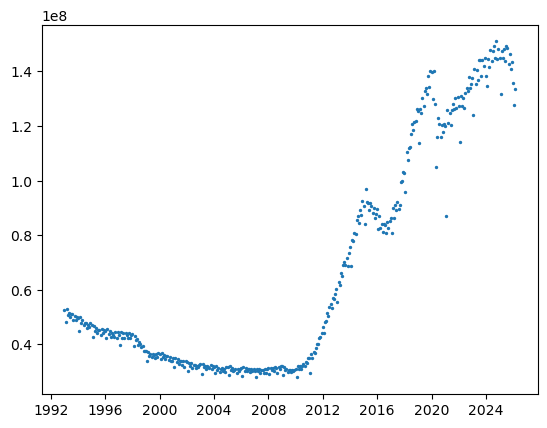

In [33]:
import matplotlib.pyplot as plt

plt.scatter(aggregate.index,aggregate.oil_sold_total_bbl,s = 2)

In [35]:
prod_well_points_2a.dropna(subset=["geometry"]).sample(
    min(5000, prod_well_points_2a["geometry"].notna().sum()),
    random_state=42
).explore(
    tiles="CartoDB positron",
    tooltip=[
        "api8"
    ]
)

: 